Q: Implement Uniform Cost Search traversal for the given graph starting from node 'A'.

UCS Traversal (List): ['A', 'B', 'D', 'C', 'F', 'E']
UCS Traversal (Path): A -> B -> D -> C -> F -> E

   Traversal
0         A
1         B
2         D
3         C
4         F
5         E


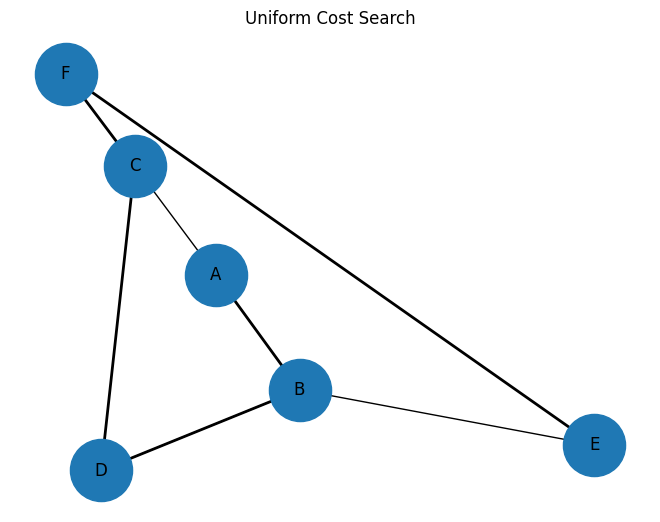

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import heapq

print("Q: Implement Uniform Cost Search traversal for the given graph starting from node 'A'.")

# Graph representation
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [],
    'F': []
}

# Uniform Cost Search Function
def ucs(g, start):
    pq = [(0, start)]   # Priority Queue
    visited = []

    while pq:
        cost, node = heapq.heappop(pq)

        if node not in visited:
            visited.append(node)

            for n, w in g[node]:
                heapq.heappush(pq, (cost + w, n))

    return visited

# Run UCS
result = ucs(graph, 'A')

# Display traversal
arrow_path = " -> ".join(result)

print("\nUCS Traversal (List):", result)
print("UCS Traversal (Path):", arrow_path)

# Display as DataFrame
print("\n", pd.DataFrame(result, columns=["Traversal"]))

# Create graph for visualization
G = nx.Graph([(u, v) for u in graph for v, _ in graph[u]])

pos = nx.spring_layout(G)

# Draw graph
nx.draw(G, pos, with_labels=True, node_size=2000)

# Highlight traversal path
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(result[i], result[i + 1]) for i in range(len(result) - 1)],
    width=2
)

plt.title("Uniform Cost Search")
plt.show()